<a href="https://colab.research.google.com/github/JulianSantos-LATAMAI/ECON-5200/blob/main/lab_10/%5BLab_10%5D_Correlation%2C_Causality%2C_and_Spurious_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr

start = "2010-01-01"
end   = "2024-12-31"

series = {
    "CPIAUCSL": "cpi",
    "UNRATE":   "unrate",
    "FEDFUNDS": "fedfunds",
    "INDPRO":   "indpro",
    "RSAFS":    "retail_sales",
    "DGS10":    "dgs10",
    "PAYEMS":   "payrolls",
    "M2SL":     "m2"
}

df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1)
df = df.resample("MS").last()   # monthly frequency
df = df.dropna()                # remove missing rows

print(df.head())
print(df.shape)

                cpi  unrate  fedfunds   indpro  retail_sales  dgs10  payrolls  \
DATE                                                                            
2010-01-01  217.488     9.8      0.11  89.3426      339093.0   3.63  129802.0   
2010-02-01  217.281     9.8      0.13  89.6779      339580.0   3.61  129706.0   
2010-03-01  217.353     9.9      0.16  90.2928      346974.0   3.84  129866.0   
2010-04-01  217.403     9.9      0.20  90.5991      349869.0   3.69  130120.0   
2010-05-01  217.290     9.6      0.20  91.8230      346858.0   3.31  130642.0   

                m2  
DATE                
2010-01-01  8477.7  
2010-02-01  8527.3  
2010-03-01  8523.5  
2010-04-01  8554.8  
2010-05-01  8609.0  
(180, 8)


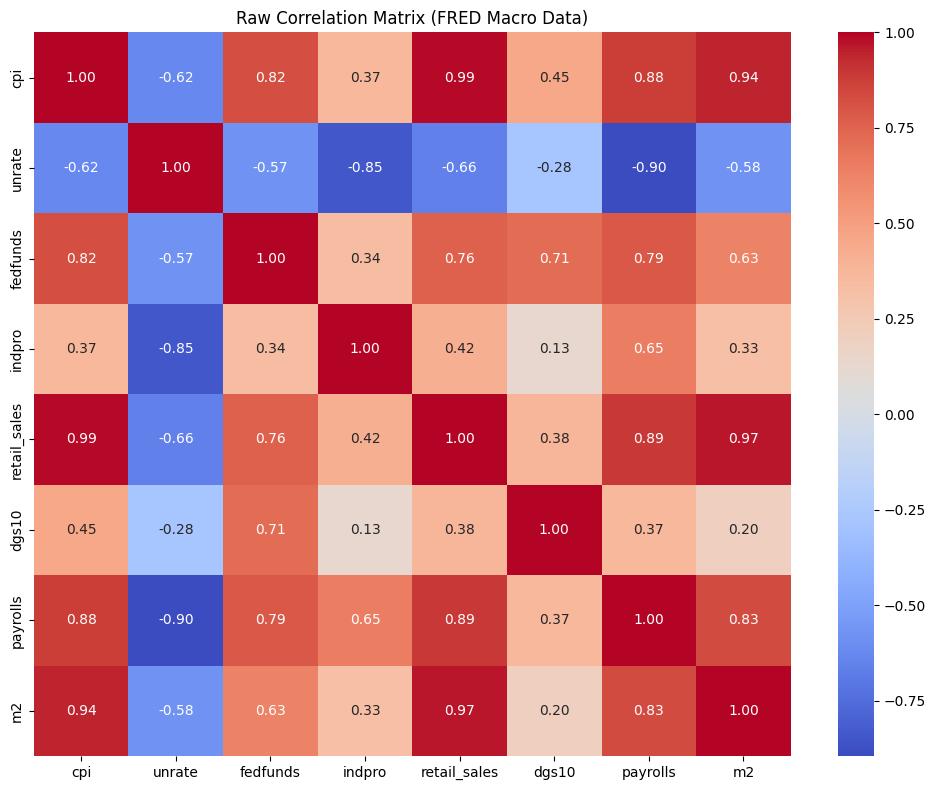

In [2]:
plt.figure(figsize=(10, 8))

corr = df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Raw Correlation Matrix (FRED Macro Data)")
plt.tight_layout()
plt.show()

In [3]:
y = df["cpi"]

X = df[[
    "unrate", "fedfunds", "indpro",
    "retail_sales", "dgs10", "payrolls", "m2"
]]

X = sm.add_constant(X)   # add intercept

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     2876.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):          1.36e-174
Time:                        16:20:19   Log-Likelihood:                -428.24
No. Observations:                 180   AIC:                             872.5
Df Residuals:                     172   BIC:                             898.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -11.9392     35.532     -0.336   

In [4]:
X_vif = df[[
    "unrate", "fedfunds", "indpro",
    "retail_sales", "dgs10", "payrolls", "m2"
]].copy()

X_vif = sm.add_constant(X_vif)   # add constant

vif_table = pd.DataFrame()
vif_table["feature"] = X_vif.columns
vif_table["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_table.sort_values("VIF", ascending=False))

        feature           VIF
0         const  31822.668903
4  retail_sales     90.864852
7            m2     83.154438
6      payrolls     74.462751
1        unrate     32.648009
2      fedfunds     16.361078
3        indpro      5.070143
5         dgs10      4.192881


In [5]:
# Round 1: drop m2 (typically highest VIF)
X_vif2 = df[[
    "unrate", "fedfunds", "indpro",
    "retail_sales", "dgs10", "payrolls"
]].copy()
X_vif2 = sm.add_constant(X_vif2)

vif_table2 = pd.DataFrame()
vif_table2["feature"] = X_vif2.columns
vif_table2["VIF"] = [
    variance_inflation_factor(X_vif2.values, i)
    for i in range(X_vif2.shape[1])
]
print("After dropping m2:")
print(vif_table2.sort_values("VIF", ascending=False))

# Round 2: also drop payrolls
X_vif3 = df[[
    "unrate", "fedfunds", "indpro",
    "retail_sales", "dgs10"
]].copy()
X_vif3 = sm.add_constant(X_vif3)

vif_table3 = pd.DataFrame()
vif_table3["feature"] = X_vif3.columns
vif_table3["VIF"] = [
    variance_inflation_factor(X_vif3.values, i)
    for i in range(X_vif3.shape[1])
]
print("\nAfter dropping m2 and payrolls:")
print(vif_table3.sort_values("VIF", ascending=False))

# Re-estimate with reduced predictor set
X_clean = sm.add_constant(df[["unrate", "fedfunds", "indpro", "retail_sales", "dgs10"]])
model_clean = sm.OLS(df["cpi"], X_clean).fit()
print("\nReduced Model Summary:")
print(model_clean.summary())

After dropping m2:
        feature           VIF
0         const  27649.367476
6      payrolls     57.823145
1        unrate     27.505891
2      fedfunds     11.102599
4  retail_sales      9.719615
3        indpro      4.658168
5         dgs10      3.661694

After dropping m2 and payrolls:
        feature          VIF
0         const  4477.284691
1        unrate     6.256793
2      fedfunds     4.806492
3        indpro     4.146343
4  retail_sales     3.292223
5         dgs10     2.347262

Reduced Model Summary:
                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     3510.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):          1.24e-172
Time:                        16:20:20   Log-Likelihood:                -441.52
No. Obs

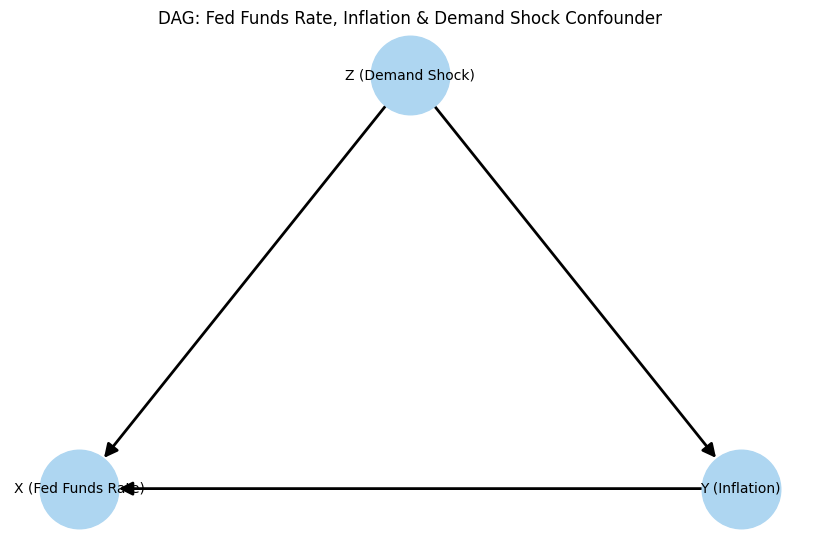

In [6]:
import networkx as nx

G = nx.DiGraph()

G.add_edges_from([
    ("Z (Demand Shock)", "X (Fed Funds Rate)"),
    ("Z (Demand Shock)", "Y (Inflation)"),
    ("Y (Inflation)", "X (Fed Funds Rate)")   # reverse causality
])

pos = {
    "Z (Demand Shock)":   (0, 1),
    "X (Fed Funds Rate)": (-1, 0),
    "Y (Inflation)":       (1, 0)
}

plt.figure(figsize=(8, 5))
nx.draw(
    G, pos, with_labels=True,
    node_size=3200, font_size=10,
    node_color="#AED6F1",
    arrows=True, arrowstyle="-|>", arrowsize=20,
    width=2
)
plt.title("DAG: Fed Funds Rate, Inflation & Demand Shock Confounder")
plt.axis("off")
plt.show()

In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plot_df = df_full_t[["cpi_yoy", "unrate", "fedfunds"]].dropna().copy()
plot_df.index = pd.to_datetime(plot_df.index)

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.07,
    subplot_titles=[
        "CPI Inflation (YoY %)",
        "Unemployment Rate (%)",
        "Federal Funds Rate (%)"
    ]
)

fig.add_trace(go.Scatter(
    x=plot_df.index, y=plot_df["cpi_yoy"],
    name="CPI Inflation", line=dict(color="firebrick", width=2)
), row=1, col=1)
fig.add_hline(y=2, line_dash="dash", line_color="gray",
              annotation_text="2% Target", row=1, col=1)

fig.add_trace(go.Scatter(
    x=plot_df.index, y=plot_df["unrate"],
    name="Unemployment", line=dict(color="steelblue", width=2)
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=plot_df.index, y=plot_df["fedfunds"],
    name="Fed Funds Rate", line=dict(color="darkorange", width=2)
), row=3, col=1)

for row in [1, 2, 3]:
    fig.add_vrect(x0="2020-03-01", x1="2021-06-01",
                  fillcolor="lightgray", opacity=0.3,
                  layer="below", line_width=0, row=row, col=1)

fig.update_layout(
    height=700,
    title_text="U.S. Macro Dashboard: Inflation, Unemployment & Fed Funds (2010–2024)",
    showlegend=False,
    hovermode="x unified"
)
fig.show()

NameError: name 'df_full_t' is not defined